In [9]:
import os, re, json, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from PIL import Image
from skimage.morphology import skeletonize
from tqdm import tqdm
pd.set_option('display.max_columns', None)

In [10]:
BASE_PATH   = '../Model/Backup'    # PASTA DOS MODELOS: '../Marcia' OU '../Model/Backup'
MARLIM_DIR  = '../Dataset/marlim'
FIGURES_DIR = 'files/comparisons'
CACHE_DIR   = 'files/cache'

STICK_TOL = 0.80    # PERMISSIVIDADE DO EXTRATOR: 0 SÓ O TRAÇO ÓBVIO, 1 TUDO QUE PARECER FALHA
STICK_MIN = 140     # PX
STICK_GAP = 59      # PX: MAIOR LACUNA COSTURADA DENTRO DE UM STICK

models = sorted(m for m in os.listdir(BASE_PATH) if os.path.isdir(f'{BASE_PATH}/{m}/marlim'))
models

['model_2', 'model_3']

In [11]:
# RESUMO DO MODELO PELO INFO.JSON, COM A JANELA DE TREINO NO RÓTULO
def modelSummary(name):
    path = f'{BASE_PATH}/{name}/info.json'
    info = json.load(open(path)) if os.path.exists(path) else {}

    size    = info.get('model', {}).get('img_size')
    size    = [] if size is None else ([size] * 3 if np.isscalar(size) else list(size))
    network = info.get('model', {}).get('network', '?')
    window  = '×'.join(str(int(s)) for s in size) if size else '?'
    iou     = info.get('trainer', {}).get('test_iou')

    return {
        'nome': name,
        'rede': network,
        'janela': window,
        'dataset': info.get('processing', {}).get('dataset', '?'),
        'iou_teste': round(float(iou), 4) if iou is not None else None,
        'rotulo': f'{name} · {network} {window}' + (f' (iou={iou:.3f})' if iou is not None else '')
    }


pd.DataFrame([modelSummary(m) for m in models])

,nome,rede,janela,dataset,iou_teste,rotulo
0,model_2,dbrnet,128×128×128,dataset_wu,0.7585,model_2 · dbrnet 128×128×128 (iou=0.758)
1,model_3,resaceunet_zu,128×128×128,dataset_wu,0.6556,model_3 · resaceunet_zu 128×128×128 (iou=0.656)


# EXTRAÇÃO DE STICKS
- Cada falha de uma seção 2D vira uma reta (**stick**), a mesma representação para a rede e para o especialista
- **Evidência**: a probabilidade suavizada e reescalada para $[0,1]$; o piso sobe pelo percentil quando a predição é densa, para a teia não explodir o traçado
- **Votação tipo Hough**: a evidência somada numa janela reta de `seedLen` px em cada orientação plausível; os picos são as sementes
- **Traçado**: a semente se estende enquanto houver suporte, tolerando lacunas de até `STICK_GAP` px, e a reta é reajustada ao centro de massa da evidência por **PCA**
- **Filtros**: mergulho entre 43° e 76°, comprimento mínimo `STICK_MIN`, preenchimento, **energia sísmica** (a falha precisa cortar refletores, não a água nem a zona morta) e **ângulo com as camadas** pelo tensor de estrutura
- **Matching pursuit**: aceita a melhor reta, consome o corredor dela e segue para a próxima; no fim, retas colineares se fundem e as que correm por cima de uma maior saem
- A anotação do especialista entra pelo `fromRaster`: esqueleto, corte nas junções e cada pedaço endireitado até caber em 7 px de desvio

In [12]:
# FALHAS DE UMA SEÇÃO 2D COMO RETAS: VOTAÇÃO TIPO HOUGH, TRAÇADO COM LACUNAS, PCA E MATCHING PURSUIT
class FaultStickExtractor:
    def __init__(self, tolerance=STICK_TOL, minLen=STICK_MIN, maxGap=STICK_GAP):
        t    = float(np.clip(tolerance, 0.0, 1.0))
        lerp = lambda a, b: a + (b - a) * t

        self.tolerance = t
        self.minLen    = float(minLen)
        self.maxGap    = int(maxGap)
        self.dipMin    = 43.0
        self.dipMax    = 76.0

        self.evSigma  = 1.0
        self.evBudget = 0.020    # FRAÇÃO DA SEÇÃO QUE SE ESPERA MARCADA; ACIMA DISSO O PISO SOBE
        self.evLo     = 0.20
        self.evHi     = 0.50

        self.scanMin   = 34.0    # VARREDURA UM POUCO MAIS LARGA QUE O MERGULHO ACEITO, PARA O PCA TER DE ONDE GIRAR
        self.angleStep = 3.0
        self.seedLen   = 140
        self.seedWidth = 5
        self.seedThr   = lerp(0.198, 0.048)
        self.maxSeeds  = 1200
        self.nmsOffset = 9
        self.nmsAlong  = 51
        self.nmsAngle  = 9.9

        self.corrWidth    = 5
        self.supThr       = lerp(0.381, 0.211)
        self.traceMax     = 560
        self.stretchGap   = 86
        self.stretchFill  = 0.385
        self.stretchWidth = 8
        self.consumeWidth = 4

        self.minFill     = lerp(0.615, 0.415)
        self.energyMin   = 0.167
        self.energyFrac  = 0.213
        self.energySigma = 25
        self.layerMin    = lerp(35.8, 25.8)
        self.layerSigma  = 12.0

        self.mergeAngle  = 8.65
        self.mergeOffset = 6.0
        self.mergeGap    = 157.0
        self.dupCover    = 0.722
        self.dupOffset   = 17.7

        self.layer = self.coh = self.energyMap = None

    # STICKS DE UM MAPA DE PROBABILIDADE; A SÍSMICA LIGA OS FILTROS DE ENERGIA E DE CORTE DAS CAMADAS
    def extract(self, prob, seismic=None):
        self.energyMap = self.energy(seismic) if seismic is not None else None
        self.layer, self.coh = self.layering(seismic) if seismic is not None else (None, None)

        q = self.evidence(prob)
        return self.build(q, self.votes(q))

    # DA EVIDÊNCIA AOS STICKS FINAIS: PERSEGUIR, FUNDIR, REMEDIR O PREENCHIMENTO E TIRAR OS REPETIDOS
    def build(self, q, votes):
        sticks = self.merge(self.pursue(q, q.copy(), self.seeds(votes)))

        for s in sticks:
            s['fill'] = self.fracAbove(q, s, self.supThr)

        sticks = [s for s in sticks if s['len'] >= self.minLen and s['fill'] >= self.minFill * 0.9]
        return sorted(self.dedup(sticks), key=lambda s: -s['len'])

    # MATCHING PURSUIT: ACEITA A MELHOR RETA, CONSOME O CORREDOR DELA, SEGUE PARA A PRÓXIMA
    def pursue(self, q, res, seeds):
        sticks = []

        for score, x, y, phi in seeds:
            s = self.trace(res, x, y, phi)

            if s is None:
                continue

            s = self.refine(q, s)
            s['fill'] = self.fracAbove(res, s, self.supThr)

            if not self.accept(s):
                continue

            s = self.refine(q, self.stretch(res, s))
            self.consume(res, s)
            sticks.append(s)

        return sticks

    # PROBABILIDADE -> EVIDÊNCIA EM [0,1]; O PISO SOBE PELO PERCENTIL PARA A PREDIÇÃO DENSA NÃO EXPLODIR O TRAÇADO
    def evidence(self, prob):
        p  = gauss(prob.astype(np.float32), self.evSigma)
        hi = max(self.evHi, float(np.percentile(p, 100 * (1 - self.evBudget))))
        lo = max(self.evLo, float(np.percentile(p, 100 * (1 - 2 * self.evBudget))))
        return np.clip((p - lo) / max(hi - lo, 1e-3), 0, 1).astype(np.float32)

    # AMPLITUDE LOCAL DA SÍSMICA: ~0 NA ÁGUA E NA ZONA MORTA, ~1 NOS REFLETORES
    def energy(self, seismic):
        sec = seismic.astype(np.float32)
        mu  = gauss(sec, self.energySigma)
        var = gauss(sec * sec, self.energySigma) - mu * mu
        E   = np.sqrt(np.clip(var, 0, None))
        return np.clip(E / (np.percentile(E, 95) + 1e-9), 0, 1).astype(np.float32)

    # TENSOR DE ESTRUTURA DA SÍSMICA -> (ÂNGULO DAS CAMADAS EM GRAUS, COERÊNCIA)
    def layering(self, seismic):
        sec = seismic.astype(np.float32)
        Ix  = cv2.Sobel(sec, cv2.CV_32F, 1, 0, ksize=3)
        Iy  = cv2.Sobel(sec, cv2.CV_32F, 0, 1, ksize=3)
        Jxx, Jyy, Jxy = gauss(Ix * Ix, self.layerSigma), gauss(Iy * Iy, self.layerSigma), gauss(Ix * Iy, self.layerSigma)

        angle = (np.degrees(0.5 * np.arctan2(2 * Jxy, Jxx - Jyy)) + 90.0) % 180.0
        coh   = np.sqrt((Jxx - Jyy) ** 2 + 4 * Jxy ** 2) / (Jxx + Jyy + 1e-9)
        return angle.astype(np.float32), coh.astype(np.float32)

    # VOTAÇÃO TIPO HOUGH: EVIDÊNCIA MÉDIA NUMA JANELA RETA, PARA CADA ORIENTAÇÃO PLAUSÍVEL
    def votes(self, q):
        canvas = int(np.ceil(np.hypot(*q.shape)))
        ones   = np.ones_like(q)
        kernel = (self.seedWidth, self.seedLen)
        area   = kernel[0] * kernel[1]
        out    = []

        for phi in np.arange(self.scanMin, 180.0 - self.scanMin + 1e-6, self.angleStep):
            M = self.rotation(q.shape, phi - 90.0, canvas)
            R = cv2.warpAffine(q, M, (canvas, canvas), flags=cv2.INTER_LINEAR, borderValue=0)
            V = cv2.warpAffine(ones, M, (canvas, canvas), flags=cv2.INTER_NEAREST, borderValue=0)

            num = cv2.boxFilter(R, -1, kernel, normalize=False, borderType=cv2.BORDER_CONSTANT)
            den = cv2.boxFilter(V, -1, kernel, normalize=False, borderType=cv2.BORDER_CONSTANT)
            acc = np.where(den > 0.6 * area, num / np.maximum(den, 1e-6), 0)

            peak   = acc >= cv2.dilate(acc, np.ones((self.seedLen // 2, 9), np.uint8))
            ys, xs = np.nonzero((acc >= self.seedThr) & peak)

            if not len(ys):
                continue

            inv = cv2.invertAffineTransform(M)
            pts = inv[:, :2] @ np.stack([xs, ys]).astype(np.float32) + inv[:, 2:3]
            out += [(float(s), float(x), float(y), float(phi)) for (x, y), s in zip(pts.T, acc[ys, xs])]

        out.sort(key=lambda r: -r[0])
        return out

    # ROTAÇÃO QUE DEIXA UMA RETA DE ÂNGULO phi VERTICAL NUMA TELA QUADRADA
    @staticmethod
    def rotation(shape, angle, canvas):
        h, w = shape
        M = cv2.getRotationMatrix2D(((w - 1) / 2, (h - 1) / 2), angle, 1.0)
        M[0, 2] += (canvas - 1) / 2 - (w - 1) / 2
        M[1, 2] += (canvas - 1) / 2 - (h - 1) / 2
        return M

    # DESCARTA VOTOS REDUNDANTES: A DISTÂNCIA QUE IMPORTA É A PERPENDICULAR, PORQUE A FAMÍLIA DOMINÓ É PARALELA
    def seeds(self, votes):
        cell, kept, grid = self.nmsAlong, [], {}

        for seed in votes:
            score, x, y, phi = seed
            gx, gy = int(x // cell), int(y // cell)
            near   = [kept[k] for i in (gx - 1, gx, gx + 1) for j in (gy - 1, gy, gy + 1) for k in grid.get((i, j), ())]

            if any(self.redundant(seed, other) for other in near):
                continue

            grid.setdefault((gx, gy), []).append(len(kept))
            kept.append(seed)

            if len(kept) >= self.maxSeeds:
                break

        return kept

    def redundant(self, seed, other):
        _, x, y, phi    = seed
        _, x2, y2, phi2 = other
        da = abs(phi - phi2) % 180

        if min(da, 180 - da) > self.nmsAngle:
            return False

        d = np.array([np.cos(np.radians(phi2)), np.sin(np.radians(phi2))])
        v = np.array([x - x2, y - y2])
        return abs(d[0] * v[1] - d[1] * v[0]) <= self.nmsOffset and abs(d @ v) <= self.nmsAlong

    # ESTENDE A SEMENTE ENQUANTO HOUVER SUPORTE, TOLERANDO LACUNAS: É ISSO QUE COSTURA OS PEDAÇOS
    def trace(self, q, x, y, phi):
        d  = np.array([np.cos(np.radians(phi)), np.sin(np.radians(phi))])
        c  = np.array([x, y], float)
        ts = np.arange(-self.traceMax, self.traceMax + 1.0)

        prof, inside = self.profile(q, c, d, ts)
        sup  = (prof >= self.supThr) & inside
        i0   = len(ts) // 2
        half = self.seedLen // 2

        if not sup[max(i0 - half, 0):i0 + half + 1].any():
            return None

        a, b = self.extent(sup, i0, self.maxGap)

        if b - a < self.minLen * 0.6:
            return None

        return self.stick(c + ts[a] * d, c + ts[b] * d, sup[a:b + 1].mean())

    # PROCURA A CONTINUAÇÃO ALÉM DAS PONTAS: DEPOIS DE VALIDADA A RETA VALE ATRAVESSAR UMA LACUNA MAIOR
    def stretch(self, q, s):
        c, d, length = self.unit(s)
        ts = np.arange(-self.traceMax, self.traceMax + 1.0)
        prof, inside = self.profile(q, c, d, ts, self.stretchWidth)
        sup = (prof >= self.supThr) & inside

        i0   = len(ts) // 2
        a0   = max(int(i0 - length / 2), 0)
        b0   = min(int(i0 + length / 2), len(ts) - 1)
        a, b = self.extent(sup, i0, int(self.stretchGap))

        if a < a0 and sup[a:a0].mean() < self.stretchFill:
            a = a0

        if b > b0 and sup[b0:b].mean() < self.stretchFill:
            b = b0

        return self.stick(c + ts[a] * d, c + ts[b] * d, sup[a:b + 1].mean())

    # REAJUSTA A RETA AO CENTRO DE MASSA DA EVIDÊNCIA DENTRO DO CORREDOR
    def refine(self, q, s, iters=2):
        for _ in range(iters):
            c, d, length = self.unit(s)

            if length < 4:
                return s

            n    = np.array([-d[1], d[0]])
            ts   = np.arange(-length / 2, length / 2 + 1.0)
            offs = np.arange(-self.corrWidth, self.corrWidth + 1)
            X    = c[0] + ts[:, None] * d[0] + offs[None, :] * n[0]
            Y    = c[1] + ts[:, None] * d[1] + offs[None, :] * n[1]

            xi, yi = X.round().astype(np.int32), Y.round().astype(np.int32)
            ok     = (yi >= 0) & (yi < q.shape[0]) & (xi >= 0) & (xi < q.shape[1])
            w      = np.zeros(X.shape, np.float32)
            w[ok]  = q[yi[ok], xi[ok]]

            if w.sum() < 1e-3:
                return s

            wf    = w.ravel()
            P     = np.stack([X.ravel(), Y.ravel()])
            cm    = (P * wf).sum(1) / wf.sum()
            P0    = P - cm[:, None]
            V     = np.linalg.eigh((P0 * wf) @ P0.T / wf.sum())[1]
            dn    = V[:, -1] * (1 if V[1, -1] >= 0 else -1)

            if abs(float(dn @ d)) < 0.985:    # REJEITA GIROS BRUSCOS
                return s

            t = dn @ P0
            s = self.stick(cm + dn * t.min(), cm + dn * t.max(), s['fill'])

        return s

    # DESCARTA O QUE NÃO PARECE FALHA: FORA DO MERGULHO, CURTA, MAL PREENCHIDA, SEM REFLETORES OU PARALELA ÀS CAMADAS
    def accept(self, s):
        if not (self.dipMin <= s['dip'] <= self.dipMax) or s['len'] < self.minLen or s['fill'] < self.minFill:
            return False

        if self.energyMap is not None:
            s['energy'] = round(self.fracAbove(self.energyMap, s, self.energyMin), 3)

            if s['energy'] < self.energyFrac:
                return False

        if self.layer is not None:
            s['cut'] = round(self.cutAngle(s), 1)

            if s['cut'] < self.layerMin:
                return False

        return True

    # ZERA O CORREDOR DA RETA ACEITA, PARA A PRÓXIMA SEMENTE NÃO REDESENHAR A MESMA FALHA
    def consume(self, res, s):
        c, d, length = self.unit(s)
        n    = np.array([-d[1], d[0]])
        ts   = np.arange(-length / 2, length / 2 + 1.0)
        offs = np.arange(-self.consumeWidth, self.consumeWidth + 1)
        xs   = (c[0] + ts[:, None] * d[0] + offs[None, :] * n[0]).round().astype(np.int32)
        ys   = (c[1] + ts[:, None] * d[1] + offs[None, :] * n[1]).round().astype(np.int32)
        ok   = (ys >= 0) & (ys < res.shape[0]) & (xs >= 0) & (xs < res.shape[1])
        res[ys[ok], xs[ok]] = 0.0

    # FUNDE OS GRUPOS DE RETAS COLINEARES NUMA SÓ, PELO PCA DAS PONTAS
    def merge(self, sticks):
        parent = list(range(len(sticks)))

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        for i in range(len(sticks)):
            for j in range(i + 1, len(sticks)):
                if self.near(sticks[i], sticks[j]):
                    parent[find(i)] = find(j)

        groups = {}

        for i in range(len(sticks)):
            groups.setdefault(find(i), []).append(i)

        out = []

        for index in groups.values():
            if len(index) == 1:
                out.append(sticks[index[0]])
                continue

            pts   = np.array([sticks[i]['p0'] for i in index] + [sticks[i]['p1'] for i in index], float)
            c     = pts.mean(0)
            P0    = (pts - c).T
            V     = np.linalg.eigh(P0 @ P0.T / len(pts))[1]
            d     = V[:, -1] * (1 if V[1, -1] >= 0 else -1)
            t     = d @ P0
            out.append(self.stick(c + d * t.min(), c + d * t.max(), np.mean([sticks[i]['fill'] for i in index])))

        return out

    # DUAS RETAS SÃO O MESMO TRAÇO: MESMA DIREÇÃO, PONTAS PRÓXIMAS E SEM DEGRAU LATERAL
    def near(self, a, b):
        da, db = self.unit(a)[1], self.unit(b)[1]

        if np.degrees(np.arccos(np.clip(abs(float(da @ db)), 0, 1))) > self.mergeAngle:
            return False

        ea = [np.array(a['p0']), np.array(a['p1'])]
        eb = [np.array(b['p0']), np.array(b['p1'])]

        if min(np.linalg.norm(x - y) for x in ea for y in eb) > self.mergeGap:
            return False

        return max(abs(da[0] * (p - ea[0])[1] - da[1] * (p - ea[0])[0]) for p in eb) <= self.mergeOffset

    # TIRA A RETA QUE JÁ CORRE POR CIMA DE OUTRA MAIOR: É O QUE POLUI A FIGURA
    def dedup(self, sticks):
        out = []

        for s in sorted(sticks, key=lambda s: -s['len']):
            if not any(self.overlap(s, o) >= self.dupCover for o in out):
                out.append(s)

        return out

    # FRAÇÃO DE a QUE CORRE COLADA EM b
    def overlap(self, a, b):
        p0, p1 = np.array(a['p0'], float), np.array(a['p1'], float)
        P      = p0 + (p1 - p0) * np.linspace(0, 1, max(int(a['len'] / 4) + 1, 2))[:, None]
        q0, q1 = np.array(b['p0'], float), np.array(b['p1'], float)
        v      = q1 - q0
        u      = np.clip(((P - q0) @ v) / (v @ v + 1e-9), 0, 1)
        return float((np.linalg.norm(P - (q0 + u[:, None] * v), axis=1) <= self.dupOffset).mean())

    # VALOR DE UM MAPA AO LONGO DA RETA: PARA CADA t, O MÁXIMO NA LARGURA DO CORREDOR
    def profile(self, m, c, d, ts, width=None):
        n    = np.array([-d[1], d[0]])
        w    = self.corrWidth if width is None else width
        offs = np.arange(-w, w + 1)
        xs   = (c[0] + ts[:, None] * d[0] + offs[None, :] * n[0]).round().astype(np.int32)
        ys   = (c[1] + ts[:, None] * d[1] + offs[None, :] * n[1]).round().astype(np.int32)
        ok   = (ys >= 0) & (ys < m.shape[0]) & (xs >= 0) & (xs < m.shape[1])

        values     = np.zeros(xs.shape, np.float32)
        values[ok] = m[ys[ok], xs[ok]]
        return values.max(1), ok.any(1)

    # MAIOR INTERVALO EM TORNO DE i0 CUJAS LACUNAS SEM SUPORTE CABEM EM maxGap
    @staticmethod
    def extent(sup, i0, maxGap):
        n, ends = len(sup), []

        for step in (1, -1):
            i, last, gap = i0, i0, 0

            while 0 <= i + step < n:
                i += step

                if sup[i]:
                    last, gap = i, 0
                    continue

                gap += 1

                if gap > maxGap:
                    break

            ends.append(last)

        return ends[1], ends[0]

    # FRAÇÃO DO COMPRIMENTO DA RETA EM QUE O MAPA PASSA DO LIMIAR
    def fracAbove(self, m, s, thr):
        c, d, length = self.unit(s)
        prof, _ = self.profile(m, c, d, np.arange(-length / 2, length / 2 + 1.0))
        return float((prof >= thr).mean())

    # ÂNGULO ENTRE A RETA E AS CAMADAS, MEDIANA PONDERADA PELA COERÊNCIA
    def cutAngle(self, s):
        c, d, length = self.unit(s)
        ts = np.arange(-length / 2, length / 2 + 1.0)
        xi = np.clip((c[0] + ts * d[0]).round().astype(int), 0, self.layer.shape[1] - 1)
        yi = np.clip((c[1] + ts * d[1]).round().astype(int), 0, self.layer.shape[0] - 1)

        diff = np.abs(self.layer[yi, xi] - np.degrees(np.arctan2(d[1], d[0])) % 180) % 180
        diff = np.minimum(diff, 180 - diff)
        w    = self.coh[yi, xi]

        if w.sum() < 1e-6:
            return 90.0

        order = np.argsort(diff)
        return float(diff[order][np.searchsorted(np.cumsum(w[order]) / w.sum(), 0.5)])

    # CENTRO, DIREÇÃO UNITÁRIA E COMPRIMENTO DE UM STICK
    @staticmethod
    def unit(s):
        p0, p1 = np.array(s['p0'], float), np.array(s['p1'], float)
        d      = p1 - p0
        length = float(np.hypot(*d)) + 1e-9
        return (p0 + p1) / 2, d / length, length

    # UM STICK: AS DUAS PONTAS, O MERGULHO ABSOLUTO, O COMPRIMENTO E O PREENCHIMENTO
    @staticmethod
    def stick(p0, p1, fill=0.0):
        d = np.asarray(p1, float) - np.asarray(p0, float)
        return {
            'p0': (float(p0[0]), float(p0[1])),
            'p1': (float(p1[0]), float(p1[1])),
            'dip': float(np.degrees(np.arctan2(abs(d[1]), abs(d[0]) + 1e-12))),
            'len': float(np.hypot(*d)),
            'fill': round(float(fill), 3)
        }

    # ANOTAÇÃO DO ESPECIALISTA -> STICKS: ESQUELETIZA, CORTA NAS JUNÇÕES E ENDIREITA OS PEDAÇOS
    @classmethod
    def fromRaster(cls, mask, maxDev=7.0, minLen=30):
        sk      = skeletonize(np.asarray(mask) > 0.5)
        nb      = ndi.convolve(sk.astype(np.uint8), np.ones((3, 3), np.uint8), mode='constant') - sk
        lbl     = ndi.label(sk & (nb <= 2), structure=np.ones((3, 3)))[0]
        out     = []

        for i, sl in enumerate(ndi.find_objects(lbl), 1):
            ys, xs = np.nonzero(lbl[sl] == i)

            if len(ys) >= minLen:
                out += cls.splitCurve(ys + sl[0].start, xs + sl[1].start, maxDev, minLen)

        tool = cls()
        tool.mergeGap, tool.mergeAngle, tool.mergeOffset = 70.0, 10.0, 10.0
        return tool.merge(out)

    # QUEBRA UM TRAÇO TORTO NO PONTO DE MAIOR DESVIO ATÉ CADA PEDAÇO CABER EM maxDev
    @classmethod
    def splitCurve(cls, ys, xs, maxDev, minLen, depth=0):
        P     = np.stack([xs, ys]).astype(float)
        c     = P.mean(1)
        P0    = P - c[:, None]
        V     = np.linalg.eigh(P0 @ P0.T / P.shape[1])[1]
        d     = V[:, -1] * (1 if V[1, -1] >= 0 else -1)
        t     = d @ P0
        dev   = np.abs(-d[1] * P0[0] + d[0] * P0[1])

        if dev.max() > maxDev and depth < 6 and len(ys) >= 2 * minLen:
            m = t <= t[int(np.argmax(dev))]

            if m.sum() >= minLen and (~m).sum() >= minLen:
                return cls.splitCurve(ys[m], xs[m], maxDev, minLen, depth + 1) + cls.splitCurve(ys[~m], xs[~m], maxDev, minLen, depth + 1)

        if t.max() - t.min() < minLen:
            return []

        return [cls.stick(c + d * t.min(), c + d * t.max(), 1.0)]


def gauss(img, sigma):
    return cv2.GaussianBlur(img, (0, 0), sigmaX=sigma, sigmaY=sigma, borderType=cv2.BORDER_REFLECT)


annotated = FaultStickExtractor.fromRaster(np.array(Image.open('files/patches/1200/1200_interpretado.png').convert('L')) > 128)
pd.DataFrame(annotated)[['dip', 'len']].describe().round(1)

,dip,len
count,33.0,33.0
mean,61.0,225.9
std,10.7,134.7
min,29.9,35.4
25%,56.5,107.3
50%,62.2,219.7
75%,68.8,306.2
max,78.7,478.9


# COMPARAÇÃO COM O ESPECIALISTA
- `FaultComparer` monta o slab de um patch a partir dos tiles `.dat` (o shape vem do `patch_metadata.json`, nunca da janela do modelo) e fica com a **inline anotada**, a fatia de maior correlação com o `<id>.png`, guardada em `files/cache`
- `recall` é a fração do comprimento anotado coberta pelos sticks preditos, `precisao` a fração do comprimento predito coberta pela anotação e `deteccao` a fração das falhas anotadas cobertas em pelo menos 50%, com casamento de 12 px e 20°
- A anotação é parcial (o especialista marca só as falhas principais), então `precisao` é limite inferior

In [13]:
# SEÇÃO ANOTADA DE UM PATCH DE MARLIM: MONTA A PREDIÇÃO, EXTRAI OS STICKS E MEDE A CONVERGÊNCIA COM O ESPECIALISTA
class FaultComparer:
    PANELS = {
        'seismic': [('sísmica', False, False, True)],
        'mask': [('máscara', True, False, True)],
        'sticks': [('sticks', False, True, True)],
        'both': [('sísmica', False, False, False), ('máscara', True, False, True)]
    }
    MATCH_TOL   = 12.0    # PX
    MATCH_ANGLE = 20.0    # GRAUS
    THRESHOLD   = 0.5
    INDEX_PATH  = f'{CACHE_DIR}/inline_index.json'

    def __init__(self, patchId, preds):
        self.patchId   = str(patchId)
        self.folder    = f'{MARLIM_DIR}/patch_{patchId}'
        self.preds     = preds
        self.extractor = FaultStickExtractor()
        self.maps      = {}
        self.lines     = {}
        self.index     = None
        self.seismic   = None

        meta       = json.load(open(f'{self.folder}/patch_metadata.json'))
        self.size  = meta['patch_size']
        self.ov    = meta['overlap_voxels']
        self.shape = tuple(meta['original_shape'])
        self.total = int(np.prod(meta['grid_shape']))    # MENOS TILES QUE ISSO É PREDIÇÃO INCOMPLETA

    # FATIA DO SLAB QUE CORRESPONDE À INLINE ANOTADA, QUE NÃO É shape[0] // 2
    @property
    def inline(self):
        if self.index is None:
            table      = self.indexTable()
            self.index = table[self.patchId] if self.patchId in table else self.locate()

        return self.index

    # SÍSMICA DA INLINE ANOTADA, DO CACHE QUANDO ELE JÁ EXISTE
    @property
    def background(self):
        if self.seismic is not None:
            return self.seismic

        cache = f'{CACHE_DIR}/real_center_{self.patchId}.npy'

        if self.patchId in self.indexTable() and os.path.exists(cache):
            self.index, self.seismic = self.indexTable()[self.patchId], np.load(cache)
            return self.seismic

        self.locate()
        return self.seismic

    # LOCALIZA A INLINE ANOTADA CORRELACIONANDO O SLAB COM A PNG DE REFERÊNCIA
    def locate(self):
        vol    = self.reconstruct(self.folder, f'localizando inline {self.patchId}')
        norm   = lambda a: (a - a.mean()) / (a.std() + 1e-9)
        target = norm(np.asarray(Image.open(f'files/patches/{self.patchId}/{self.patchId}.png').convert('L'), np.float32))
        corr   = [float((norm(vol[k].astype(np.float32)) * target).mean()) for k in range(vol.shape[0])]

        self.index   = int(np.argmax(corr))
        self.seismic = vol[self.index].copy()
        print(f'[{self.patchId}] inline anotada na fatia {self.index}/{vol.shape[0]} (r={max(corr):.3f})')

        os.makedirs(CACHE_DIR, exist_ok=True)
        np.save(f'{CACHE_DIR}/real_center_{self.patchId}.npy', self.seismic)
        json.dump({**self.indexTable(), self.patchId: self.index}, open(self.INDEX_PATH, 'w'), indent=2)
        return self.index

    # OS TILES DA PASTA CONFERIDOS CONTRA O GRID DO PATCH; FALTANDO UM, O QUE SOBRA SAIRIA ZERADO NO VOLUME
    def grid(self, path):
        tiles = [(f, re.match(r'patch_d(\d+)_h(\d+)_w(\d+)\.dat', f)) for f in sorted(os.listdir(path))]
        tiles = [(f, m.groups()) for f, m in tiles if m]

        if len(tiles) != self.total:
            raise FileNotFoundError(f'{path}: {len(tiles)} tiles de {self.total}, predição incompleta')

        return tiles

    # MONTA O SLAB A PARTIR DOS TILES; O SHAPE VEM DO PATCH_METADATA, NUNCA DA JANELA DO MODELO
    def reconstruct(self, path, desc='montando'):
        ps, ov  = (self.size,) * 3, (self.ov,) * 3
        stride  = tuple(p - 2 * o for p, o in zip(ps, ov))
        lastIdx = [n // s for n, s in zip(self.shape, stride)]
        vol     = np.zeros(self.shape, np.float32)

        for name, index in tqdm(self.grid(path), desc=desc):
            origin = [max(0, size - st) if idx == last else idx * st for idx, last, size, st in zip(map(int, index), lastIdx, self.shape, stride)]
            data   = np.fromfile(f'{path}/{name}', np.float32)

            if data.size != int(np.prod(ps)):
                raise ValueError(f'{name}: {data.size} valores, esperado {ps}')

            core       = data.reshape(ps)[ov[0]:ps[0] - ov[0], ov[1]:ps[1] - ov[1], ov[2]:ps[2] - ov[2]]
            d, h, w    = origin
            cd, ch, cw = [min(c, s - o) for c, s, o in zip(core.shape, self.shape, origin)]
            vol[d:d + cd, h:h + ch, w:w + cw] = core[:cd, :ch, :cw]

        return vol

    # SEÇÃO 2D DE UMA PREDIÇÃO: A PNG DA ANOTAÇÃO OU A INLINE DOS TILES PREDITOS
    def section(self, label):
        if label in self.maps:
            return self.maps[label]

        path = next(p for p in self.preds if p['label'] == label)['path']
        sec  = np.array(Image.open(path).convert('L')) > 128 if self.isAnnotation(path) else self.reconstruct(f'{path}/masks', label)[self.inline]
        self.maps[label] = np.asarray(sec, np.float32)
        return self.maps[label]

    # INJETA UMA SEÇÃO JÁ CALCULADA, PARA NÃO REMONTAR O MESMO VOLUME DUAS VEZES
    def setSection(self, label, section):
        self.maps[label] = np.asarray(section, np.float32)

    # STICKS DE UMA PREDIÇÃO; A ANOTAÇÃO ENTRA PELO fromRaster, NA MESMA REPRESENTAÇÃO
    def sticks(self, label):
        if label not in self.lines:
            path = next(p for p in self.preds if p['label'] == label)['path']
            self.lines[label] = FaultStickExtractor.fromRaster(self.section(label)) if self.isAnnotation(path) else self.extractor.extract(self.section(label), seismic=self.background)

        return self.lines[label]

    # CONVERGÊNCIA DOS STICKS DE label COM OS DO ESPECIALISTA
    def metrics(self, label, hit=0.5):
        mine, gt = self.sticks(label), self.sticks(self.reference())
        gtCov    = np.array([self.covered(g, mine) for g in gt])
        myCov    = np.array([self.covered(m, gt) for m in mine])
        gtLen    = np.array([g['len'] for g in gt])
        myLen    = np.array([m['len'] for m in mine])

        R = float((gtCov * gtLen).sum() / (gtLen.sum() + 1e-9))
        P = float((myCov * myLen).sum() / (myLen.sum() + 1e-9))
        return {
            'modelo': label,
            'recall': round(R, 3),
            'deteccao': round(float((gtCov >= hit).mean()) if len(gtCov) else 0.0, 3),
            'precisao': round(P, 3),
            'f1': round(2 * R * P / (R + P + 1e-9), 3),
            'sticks': len(mine),
            'falhas_gt': len(gt),
            'len_p50': round(float(np.median(myLen)), 1) if len(myLen) else 0.0,
            'len_total': int(myLen.sum()),
            'len_total_gt': int(gtLen.sum())
        }

    # FRAÇÃO DO COMPRIMENTO DE a QUE PASSA A MENOS DE MATCH_TOL DE ALGUM DOS OUTROS, COM A MESMA DIREÇÃO
    def covered(self, a, others):
        P   = self.sample(a)
        hit = np.zeros(len(P), bool)

        for o in others:
            da = abs(self.angle(a) - self.angle(o)) % 180

            if min(da, 180 - da) > self.MATCH_ANGLE:
                continue

            p0, p1 = np.array(o['p0'], float), np.array(o['p1'], float)
            v      = p1 - p0
            t      = np.clip(((P - p0) @ v) / (v @ v + 1e-9), 0, 1)
            hit   |= np.linalg.norm(P - (p0 + t[:, None] * v), axis=1) <= self.MATCH_TOL

        return float(hit.mean())

    def reference(self):
        return next(p['label'] for p in self.preds if self.isAnnotation(p['path']))

    def indexTable(self):
        return json.load(open(self.INDEX_PATH)) if os.path.exists(self.INDEX_PATH) else {}

    @staticmethod
    def isAnnotation(path):
        return str(path).lower().endswith('.png')

    @staticmethod
    def sample(s, step=1.0):
        p0, p1 = np.array(s['p0'], float), np.array(s['p1'], float)
        n = max(int(np.linalg.norm(p1 - p0) / step) + 1, 2)
        return p0 + (p1 - p0) * np.linspace(0, 1, n)[:, None]

    @staticmethod
    def angle(s):
        d = np.array(s['p1'], float) - np.array(s['p0'], float)
        return float(np.degrees(np.arctan2(d[1], d[0])) % 180)

    # UMA FIGURA DO PAINEL PEDIDO; save GRAVA EM DISCO EM VEZ DE MOSTRAR
    def show(self, mode='seismic', title=None, save=None):
        panels    = self.PANELS[mode]
        empty     = np.zeros(self.shape[1:])
        seismic   = self.background
        fig, axes = plt.subplots(1, len(panels), figsize=(15 * len(panels), 9), squeeze=False)

        for ax, (name, dark, asSticks, draw) in zip(axes[0], panels):
            ax.imshow(empty if dark else seismic, cmap='gray', aspect='auto', zorder=0)
            detail = f'tolerance {self.extractor.tolerance}' if asSticks else f'threshold {self.THRESHOLD}'
            header = name if not draw else f'{name} ({detail})'
            ax.set_title(f'{title} — {header}' if title else header)

            if not draw:
                continue

            self.plotPreds(ax, asSticks)
            ax.legend(handles=[Patch(facecolor=to_rgb(p['color']), label=p['label']) for p in self.preds], loc='upper right', framealpha=0.9)

        plt.tight_layout()

        if save:
            os.makedirs(os.path.dirname(save), exist_ok=True)
            plt.savefig(save, dpi=200, bbox_inches='tight')
            plt.close(fig)
            return print(f'figura salva em {save}')

        plt.show()

    # AS PREDIÇÕES SOBRE O PAINEL: PONTOS PARA A ANOTAÇÃO, MÁSCARA OU STICKS PARA AS REDES
    def plotPreds(self, ax, asSticks):
        for i, p in enumerate(self.preds):
            color, z = to_rgb(p['color']), 2 + i

            if asSticks:
                for s in self.sticks(p['label']):
                    ax.plot([s['p0'][0], s['p1'][0]], [s['p0'][1], s['p1'][1]], color=color, lw=2.2 if self.isAnnotation(p['path']) else 1.6, zorder=z)
                continue

            if self.isAnnotation(p['path']):
                gy, gx = np.where(self.section(p['label']) > 0.5)
                ax.scatter(gx, gy, s=0.05, c=[color], alpha=0.8, zorder=z)
                continue

            rgba = np.zeros((*self.shape[1:], 4), np.float32)
            rgba[..., :3] = color
            rgba[..., 3]  = self.section(p['label']) >= self.THRESHOLD
            ax.imshow(rgba, aspect='auto', zorder=z)

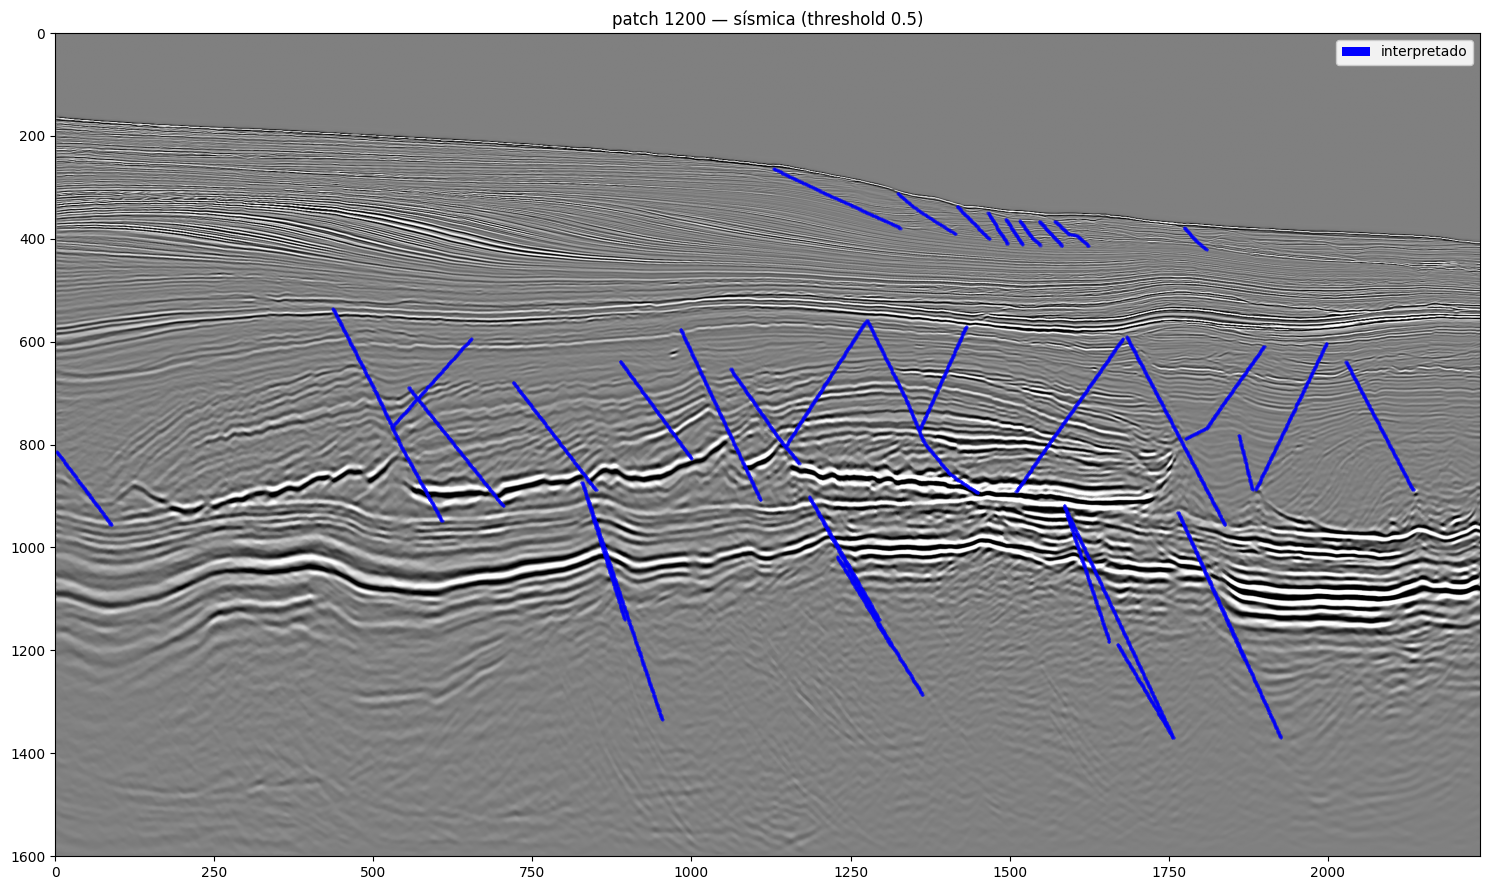

In [14]:
PATCH = 1200
MODEL = models[0]

model    = modelSummary(MODEL)
preds    = [
    {'label': 'interpretado', 'path': f'files/patches/{PATCH}/{PATCH}_interpretado.png', 'color': 'blue'}
]
comparer = FaultComparer(PATCH, preds)
comparer.show('seismic', title=f'patch {PATCH}')

model_2 · dbrnet 128×128×128 (iou=0.758): 100%|██████████| 910/910 [00:01<00:00, 640.54it/s]


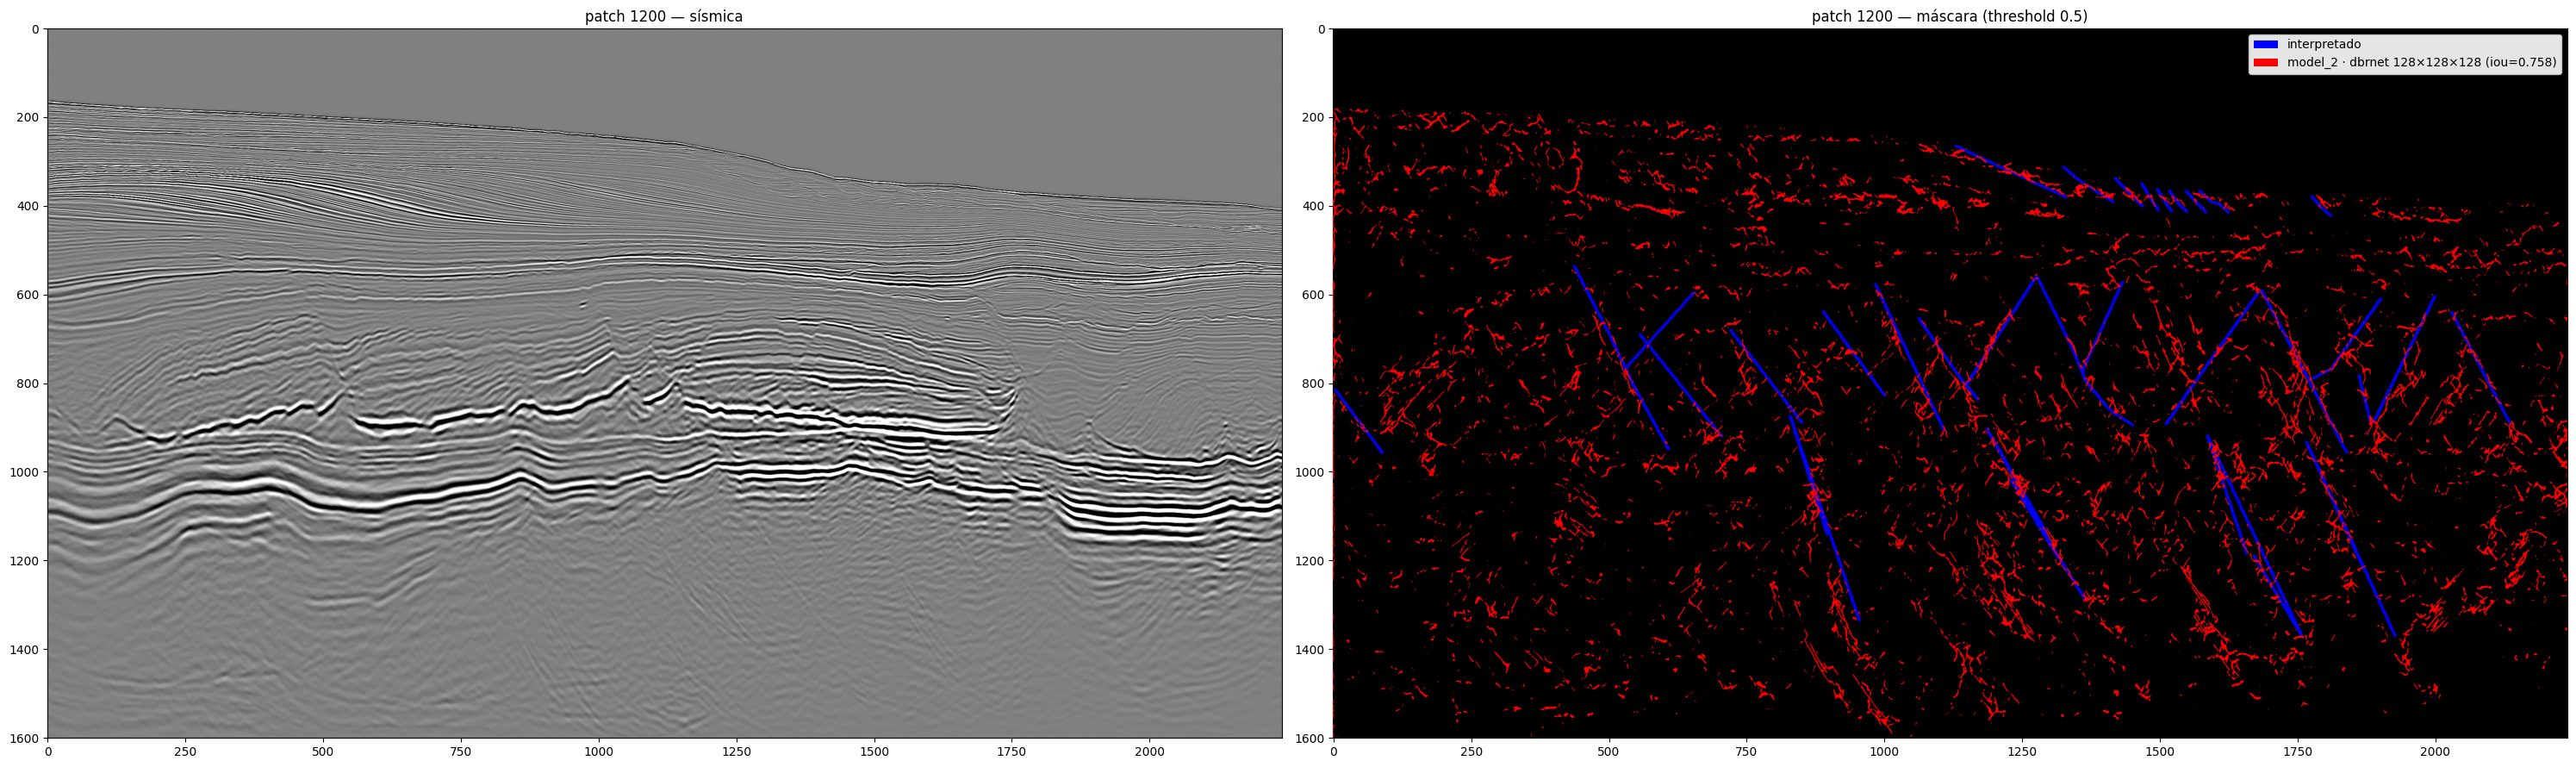

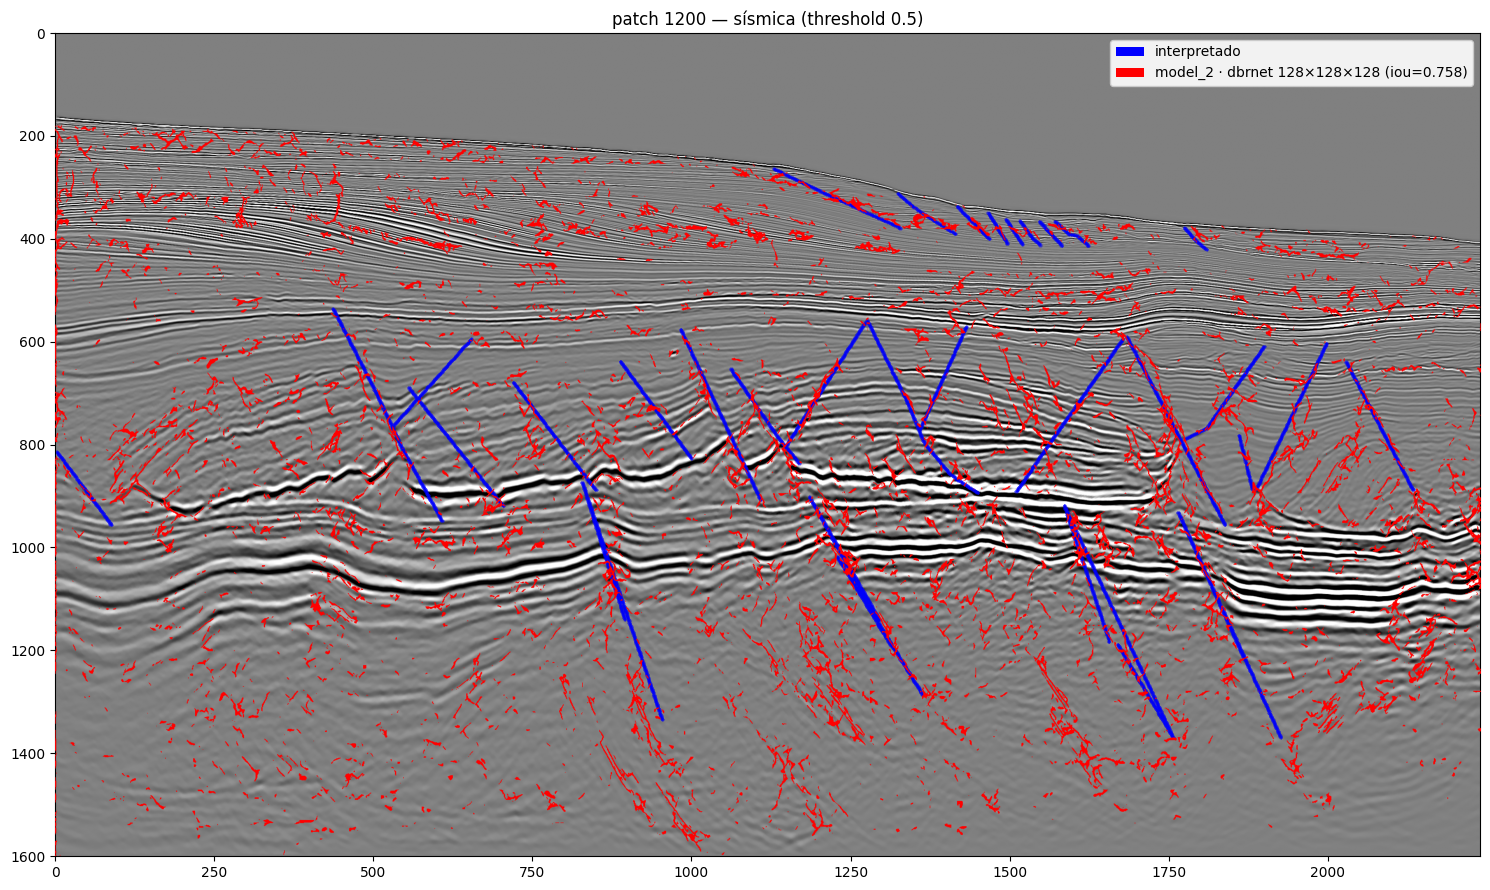

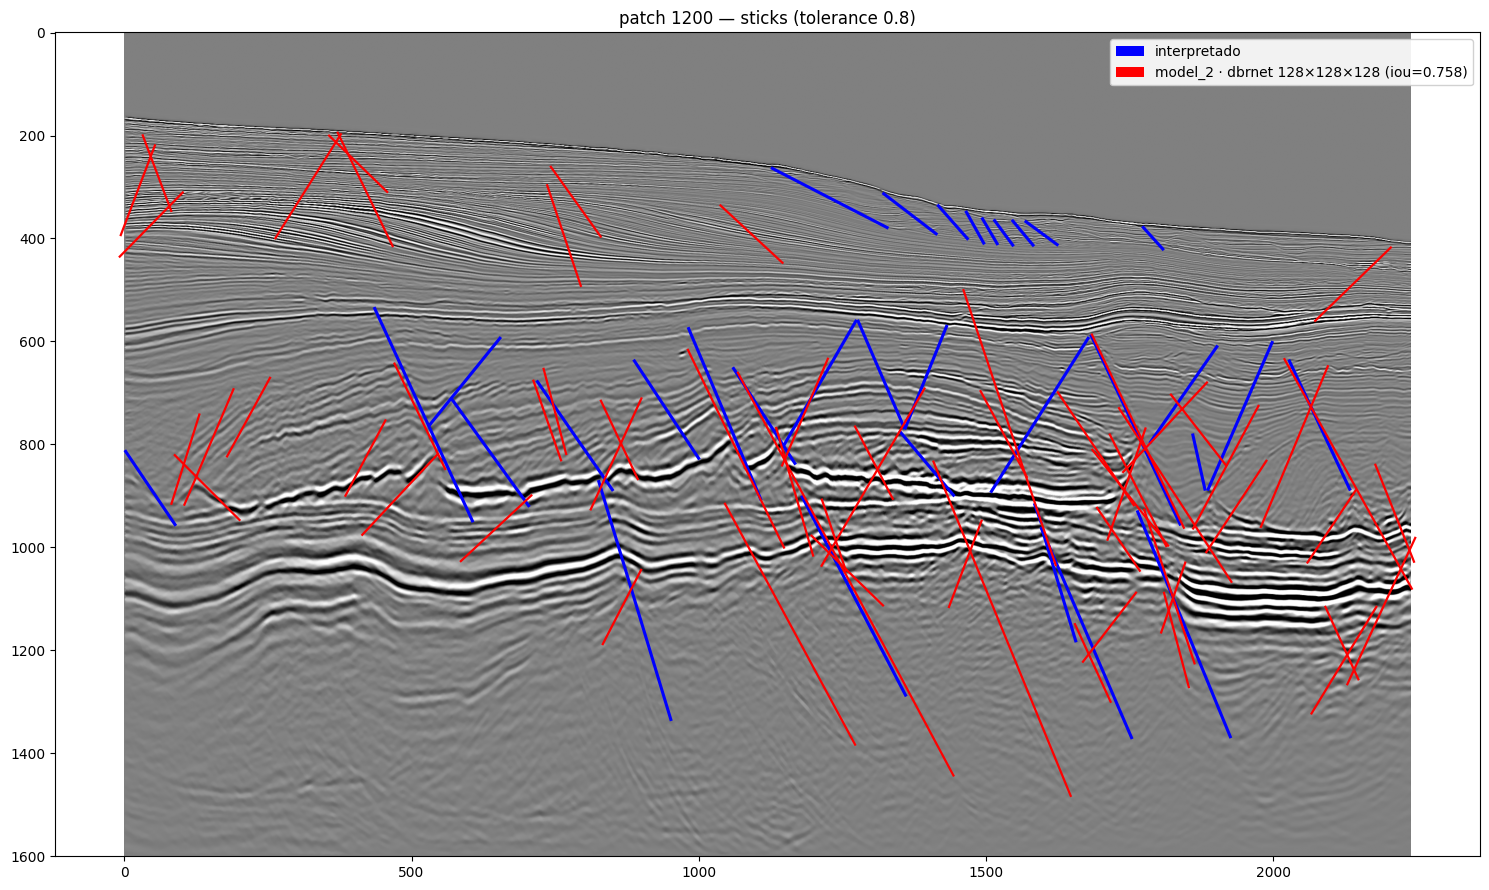

{'modelo': 'model_2 · dbrnet 128×128×128 (iou=0.758)',
 'recall': 0.41,
 'deteccao': 0.364,
 'precisao': 0.233,
 'f1': 0.297,
 'sticks': 59,
 'falhas_gt': 33,
 'len_p50': 200.0,
 'len_total': 14634,
 'len_total_gt': 7454}

In [15]:
PATCH = 1200
MODEL = models[0]

model    = modelSummary(MODEL)
preds    = [
    {'label': 'interpretado', 'path': f'files/patches/{PATCH}/{PATCH}_interpretado.png', 'color': 'blue'},
    {'label': model['rotulo'], 'path': f'{BASE_PATH}/{MODEL}/marlim/patch_{PATCH}', 'color': 'red'}
]
comparer = FaultComparer(PATCH, preds)

for mode in ('both', 'seismic', 'sticks'):
    comparer.show(mode, title=f'patch {PATCH}')

comparer.metrics(model['rotulo'])

# RECONSTRUÇÃO DAS PREDIÇÕES
- Para cada modelo com `marlim/`, cada patch predito vira o volume `predicted.npy` e três figuras (`predicted_seismic`, `predicted_mask`, `predicted_sticks`) na pasta do patch
- `overlap` é a sobreposição que o `1 - Predict.ipynb` registrou no `predict.json`; um patch com tiles faltando fica fora da tabela

In [16]:
REBUILD = True    # True REMONTA O VOLUME MESMO QUANDO O predicted.npy JÁ EXISTE

# MONTA O VOLUME PREDITO DE UM PATCH, SALVA AS TRÊS FIGURAS E DEVOLVE A LINHA DA TABELA
def comparePatch(model, patchDir):
    patchId  = os.path.basename(patchDir).replace('patch_', '')
    preds    = [{'label': 'interpretado', 'path': f'files/patches/{patchId}/{patchId}_interpretado.png', 'color': 'blue'}, {'label': model['rotulo'], 'path': patchDir, 'color': 'red'}]
    comparer = FaultComparer(patchId, preds)
    npyPath  = f'{patchDir}/predicted.npy'

    try:
        comparer.grid(f'{patchDir}/masks')
    except FileNotFoundError as error:
        return print(error)

    if REBUILD or not os.path.exists(npyPath):
        np.save(npyPath, comparer.reconstruct(f'{patchDir}/masks', desc=f'{model["nome"]}/patch_{patchId}'))

    comparer.setSection(model['rotulo'], np.load(npyPath, mmap_mode='r')[comparer.inline])
    title   = f'patch_{patchId} (fatia {comparer.inline}) — {model["rotulo"]}'
    metrics = comparer.metrics(model['rotulo'])
    caption = f'{title} — recall={metrics["recall"]} deteccao={metrics["deteccao"]} precisao={metrics["precisao"]}'

    comparer.show('seismic', title=title, save=f'{patchDir}/predicted_seismic.png')
    comparer.show('mask', title=title, save=f'{patchDir}/predicted_mask.png')
    comparer.show('sticks', title=caption, save=f'{patchDir}/predicted_sticks.png')

    run  = json.load(open(f'{patchDir}/predict.json')) if os.path.exists(f'{patchDir}/predict.json') else {}
    info = {key: model[key] for key in ('rede', 'janela', 'iou_teste')}
    return {'modelo': model['nome'], **info, 'overlap': run.get('overlap'), 'patch': patchId, 'fatia': comparer.inline, **{k: v for k, v in metrics.items() if k != 'modelo'}}


rows = [comparePatch(modelSummary(name), f'{BASE_PATH}/{name}/marlim/{patch}') for name in models for patch in sorted(os.listdir(f'{BASE_PATH}/{name}/marlim'))]
rows = [row for row in rows if row]
pd.DataFrame(rows)

model_2/patch_1200: 100%|██████████| 910/910 [00:01<00:00, 475.24it/s]


figura salva em ../Model/Backup/model_2/marlim/patch_1200/predicted_seismic.png
figura salva em ../Model/Backup/model_2/marlim/patch_1200/predicted_mask.png
figura salva em ../Model/Backup/model_2/marlim/patch_1200/predicted_sticks.png


model_3/patch_1200: 100%|██████████| 910/910 [00:01<00:00, 532.79it/s]


figura salva em ../Model/Backup/model_3/marlim/patch_1200/predicted_seismic.png
figura salva em ../Model/Backup/model_3/marlim/patch_1200/predicted_mask.png
figura salva em ../Model/Backup/model_3/marlim/patch_1200/predicted_sticks.png


,modelo,rede,janela,iou_teste,overlap,patch,fatia,recall,deteccao,precisao,f1,sticks,falhas_gt,len_p50,len_total,len_total_gt
0,model_2,dbrnet,128×128×128,0.7585,0.25,1200,16,0.410,0.364,0.233,0.297,59,33,200.0,14634,7454
1,model_3,resaceunet_zu,128×128×128,0.6556,0.25,1200,16,0.492,0.394,0.231,0.314,71,33,219.0,18460,7454


# SALVANDO A TABELA
- A tabela junta as linhas novas às do CSV anterior: um par (modelo, patch) recalculado substitui o antigo, e rede, janela e IoU de teste são relidos do `info.json`

In [17]:
REPORT_PATH = f'{FIGURES_DIR}/sticks_report_{os.path.basename(BASE_PATH.rstrip("/")).lower()}.csv'
report      = pd.DataFrame(rows)
previous    = pd.read_csv(REPORT_PATH, dtype={'patch': str}) if os.path.exists(REPORT_PATH) else pd.DataFrame(columns=report.columns)
previous    = previous[[key not in set(zip(report.modelo, report.patch)) for key in zip(previous.modelo, previous.patch)]].copy()

for column in ('rede', 'janela', 'iou_teste'):
    previous[column] = [modelSummary(name)[column] for name in previous.modelo]

report = pd.concat([report, previous], ignore_index=True).sort_values(['patch', 'recall'], ascending=[True, False]).reset_index(drop=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
report.to_csv(REPORT_PATH, index=False)
report

,modelo,rede,janela,iou_teste,overlap,patch,fatia,recall,deteccao,precisao,f1,sticks,falhas_gt,len_p50,len_total,len_total_gt
0,model_6,?,?,NaN,0.25,1200,16,0.639,0.545,0.214,0.321,94,33,247.0,30118,7454
1,model_22,?,?,NaN,0.25,1200,16,0.588,0.545,0.283,0.382,63,33,223.1,17600,7454
2,model_26,?,?,NaN,0.25,1200,16,0.586,0.545,0.244,0.344,72,33,290.0,23642,7454
3,model_24,?,?,NaN,0.25,1200,16,0.566,0.455,0.318,0.407,55,33,229.1,15786,7454
4,model_9,?,?,NaN,0.25,1200,16,0.548,0.364,0.159,0.246,84,33,343.5,32655,7454
5,model_7,?,?,NaN,0.25,1200,16,0.496,0.364,0.266,0.346,60,33,226.5,15153,7454
6,model_8,?,?,NaN,0.25,1200,16,0.494,0.394,0.195,0.280,71,33,239.0,23837,7454
7,model_3,resaceunet_zu,128×128×128,0.6556,0.25,1200,16,0.492,0.394,0.231,0.314,71,33,219.0,18460,7454
8,model_4,?,?,NaN,0.25,1200,16,0.491,0.394,0.262,0.342,61,33,248.0,16860,7454
9,model_23,?,?,NaN,0.25,1200,16,0.487,0.424,0.279,0.354,56,33,255.0,16651,7454
